# German Credit Risk - Supervised Classification Study
**COMP4030 Data Science with Machine Learning | University of Nottingham - UK**

**Author:Mohammed Adnan**

## Research Question
Can we predict whether a loan applicant is a good or bad credit risk and does cost of misclassification change which model a bank should prefer? 
## Dataset
Hofmann, H. (1994). Statlog (German Credit Data). UCI ML Repository. https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

dataset contains 1000 loan applicants with 20 features, mix of numerical and categorical. Target is good or bad credit risk. dataset also comes with a official cost matrix - misclassifying bad applicant as good costs 5x more than reverse, which signifies accuracy alone is not a good metric for this perticular problem.

---

## Notebook Structure

| Stage | Description |
|---|---|
| Stage 0 | Environment setup - imports and reproducibility |
| Stage 1 | Data loading from UCI repository |
| Stage 2 | Exploratory data analysis and feature selection |
| Stage 3 | Preprocessing - encoding, splitting, scaling |
| Stage 4 | Cross validation setup |
| Stage 5 | Modelling - Dummy, Logistic regression (LR), Decision Tree, Random Forest, K-Nearest Neighbors (KNN)|
| Stage 6 | Feature importance analysis |
| Stage 7 | Threshold tuning - Logistic regression and Random Forest |
| Stage 8 | Results, discussion and model comparison |

---
## Stage 0 - Environment Setup & Reproducibility
All package imports and random seeds are declared here so the notebook can be run end-to-end without any manual intervention.

In [42]:
# install all required packages to ensure notebook runs on any system
import subprocess, sys

packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'ucimlrepo',
]

for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

print("All packages installed successfully")

All packages installed successfully


In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV,
    cross_val_score, cross_validate,
    train_test_split
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, make_scorer
)

from ucimlrepo import fetch_ucirepo

# Global seed - every random operation uses this for reproducibility
SEED = 42
np.random.seed(SEED)

# Plot styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("All imports successful")

All imports successful


## Stage 1 - Data Loading
Data is fetched directly from UCI ML Repository using ucimlrepo package.

In [3]:
# Fetch directly from UCI ML Repository (id=144 is Statlog German Credit)
dataset = fetch_ucirepo(id=144)

X_raw = dataset.data.features.copy()
y_raw = dataset.data.targets.copy()

print("Shape of X:", X_raw.shape)
print("Shape of y:", y_raw.shape)
print("\nColumn names:")
print(list(X_raw.columns))
print("\nFirst 3 rows:")
X_raw.head(5)

Shape of X: (1000, 20)
Shape of y: (1000, 1)

Column names:
['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5', 'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10', 'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14', 'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18', 'Attribute19', 'Attribute20']

First 3 rows:


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [4]:
# Exploring the dataset
print("Target column name:", y_raw.columns.tolist())
print("\nTarget value counts:")
print(y_raw.iloc[:, 0].value_counts())
print("\nX dtypes:")
print(X_raw.dtypes)
print("\nMissing values:", X_raw.isnull().sum().sum())

Target column name: ['class']

Target value counts:
class
1    700
2    300
Name: count, dtype: int64

X dtypes:
Attribute1       str
Attribute2     int64
Attribute3       str
Attribute4       str
Attribute5     int64
Attribute6       str
Attribute7       str
Attribute8     int64
Attribute9       str
Attribute10      str
Attribute11    int64
Attribute12      str
Attribute13    int64
Attribute14      str
Attribute15      str
Attribute16    int64
Attribute17      str
Attribute18    int64
Attribute19      str
Attribute20      str
dtype: object

Missing values: 0


In [5]:
# Rename Attribute1 to 20 to meaningful names based on UCI documentation
col_rename = {
    'Attribute1':  'checking_status',
    'Attribute2':  'duration',
    'Attribute3':  'credit_history',
    'Attribute4':  'purpose',
    'Attribute5':  'credit_amount',
    'Attribute6':  'savings_status',
    'Attribute7':  'employment',
    'Attribute8':  'installment_commitment',
    'Attribute9':  'personal_status',
    'Attribute10': 'other_parties',
    'Attribute11': 'residence_since',
    'Attribute12': 'property_magnitude',
    'Attribute13': 'age',
    'Attribute14': 'other_payment_plans',
    'Attribute15': 'housing',
    'Attribute16': 'existing_credits',
    'Attribute17': 'job',
    'Attribute18': 'num_dependents',
    'Attribute19': 'own_telephone',
    'Attribute20': 'foreign_worker',
}

X_raw.rename(columns=col_rename, inplace=True)

# Recode target: 1 (Good) -> 0,  2 (Bad) -> 1
# Bad = positive class because that is the risk we want to detect
y = (y_raw['class'].values == 2).astype(int)

print("Columns after rename:")
print(list(X_raw.columns))
print("\nTarget distribution after recode:")
print(f"  Good (0): {(y == 0).sum()}")
print(f"  Bad  (1): {(y == 1).sum()}")

Columns after rename:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'residence_since', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone', 'foreign_worker']

Target distribution after recode:
  Good (0): 700
  Bad  (1): 300


## Stage 2 - Exploratory Data Analysis
In this stage we explore the distrbution of features, class balance and relationship between features and the target variable. Overall, The goal is to understand the data before making any modelling decisions and to identify which features are useful and which are not.

In [6]:
# separate the features into numerical and categorical
# this is important because we will treat them differently during preprocessing

numerical_cols = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}):")
print(numerical_cols)

print(f"\nCategorical features ({len(categorical_cols)}):")
print(categorical_cols)

Numerical features (7):
['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical features (13):
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [7]:
# look at the basic statistics of numerical features
# this helps us understand the range and spread of each feature
# and spot any obvious outliers before we do EDA

print("Basic statistics of numerical features:")
X_raw[numerical_cols].describe().round(2)

Basic statistics of numerical features:


,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,20.90,3271.26,2.97,2.84,35.55,1.41,1.16
std,12.06,2822.74,1.12,1.10,11.38,0.58,0.36
min,4.00,250.00,1.00,1.00,19.00,1.00,1.00
25%,12.00,1365.50,2.00,2.00,27.00,1.00,1.00
50%,18.00,2319.50,3.00,3.00,33.00,1.00,1.00
75%,24.00,3972.25,4.00,4.00,42.00,2.00,1.00
max,72.00,18424.00,4.00,4.00,75.00,4.00,2.00


### Categorical Feature Analysis
To understand which categorical features are most useful we calculate the bad rate - proportion of Bad applicants - for each category within each feature. Features where bad rate varies a lot across categories are more discriminative and more useful for classification.

In [8]:
# check how many unique values each categorical feature has
# this helps us understand the cardinality before encoding
# high cardinality features can cause issues with one-hot encoding

print("Unique value counts per categorical feature:")
for col in categorical_cols:
    unique_vals = X_raw[col].nunique()
    vals = X_raw[col].unique().tolist()
    print(f"  {col} ({unique_vals}): {vals}")

Unique value counts per categorical feature:
  checking_status (4): ['A11', 'A12', 'A14', 'A13']
  credit_history (5): ['A34', 'A32', 'A33', 'A30', 'A31']
  purpose (10): ['A43', 'A46', 'A42', 'A40', 'A41', 'A49', 'A44', 'A45', 'A410', 'A48']
  savings_status (5): ['A65', 'A61', 'A63', 'A64', 'A62']
  employment (5): ['A75', 'A73', 'A74', 'A71', 'A72']
  personal_status (4): ['A93', 'A92', 'A91', 'A94']
  other_parties (3): ['A101', 'A103', 'A102']
  property_magnitude (4): ['A121', 'A122', 'A124', 'A123']
  other_payment_plans (3): ['A143', 'A141', 'A142']
  housing (3): ['A152', 'A153', 'A151']
  job (4): ['A173', 'A172', 'A174', 'A171']
  own_telephone (2): ['A192', 'A191']
  foreign_worker (2): ['A201', 'A202']


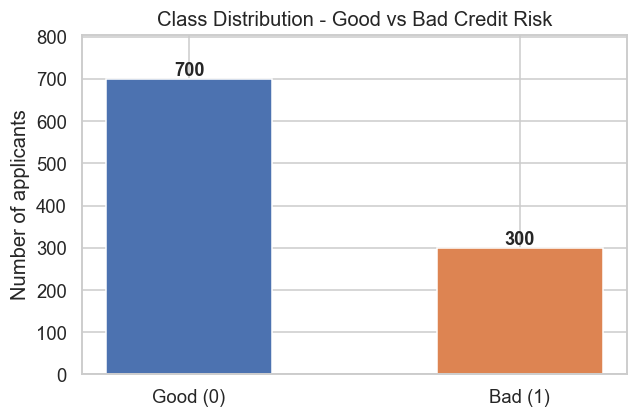

Good (0): 700 (70.0%)
Bad  (1): 300 (30.0%)


In [9]:
# visualise the class distribution to understand the imbalance
# this is important because it affects which evaluation metric we use

fig, ax = plt.subplots(figsize=(6, 4))

class_counts = pd.Series(y).value_counts().sort_index()
bars = ax.bar(['Good (0)', 'Bad (1)'], class_counts.values,
              color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)

# add count labels on top of each bar
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 8,
            str(val), ha='center', fontsize=12, fontweight='bold')
    
# set title and labels
ax.set_title('Class Distribution - Good vs Bad Credit Risk')
ax.set_ylabel('Number of applicants')
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Good (0): {class_counts[0]} ({class_counts[0]/len(y)*100:.1f}%)")
print(f"Bad  (1): {class_counts[1]} ({class_counts[1]/len(y)*100:.1f}%)")

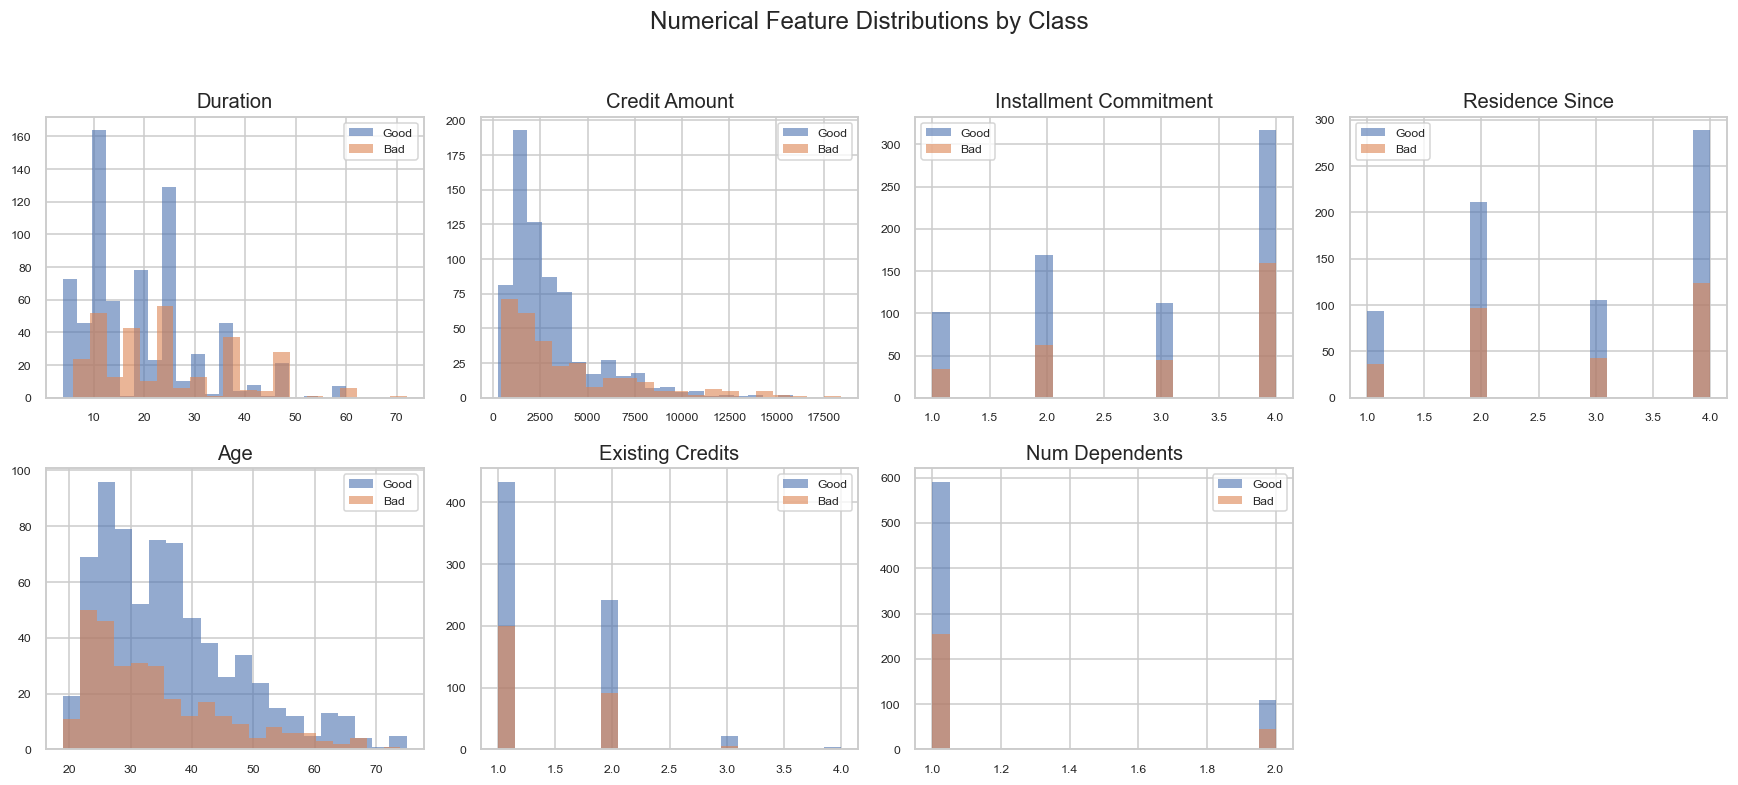

In [10]:
# plot distribution of each numerical feature split by class
# this helps us see which numerical features separate Good and Bad applicants

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

df_num = X_raw[numerical_cols].copy()
df_num['target'] = y

# plot histograms for each numerical feature, overlaying Good and Bad distributions
for i, col in enumerate(numerical_cols):
    good = df_num[df_num['target'] == 0][col]
    bad  = df_num[df_num['target'] == 1][col]

    axes[i].hist(good, bins=20, alpha=0.6, color='#4C72B0', label='Good', edgecolor='none')
    axes[i].hist(bad,  bins=20, alpha=0.6, color='#DD8452', label='Bad',  edgecolor='none')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

# hide the unused last subplot
axes[-1].set_visible(False)

plt.suptitle('Numerical Feature Distributions by Class', y=1.02)
plt.tight_layout()
plt.show()

### Feature Selection
Upon EDA below we observe that three features show near-zero class separation and have no significant logical relevance to credit risk. `own_telephone` has lowest bad rate variance of 0.0006, `num_dependents` has variance of 0.13 where almost all applicants have same value, and `residence_since` shows almost same distrbution for both Good and Bad applicants. With that these three features are removed before preprocessing. We will later validate this decision using Random Forest feature importance in Stage 6

In [41]:
# calculate the bad rate (proportion of Bad applicants) for each category
# features where bad rate varies a lot across categories are more useful

df_cat = X_raw[categorical_cols].copy()
df_cat['target'] = y

print("Bad rate per category for each categorical feature:")

for col in categorical_cols:
    bad_rate = df_cat.groupby(col)['target'].mean().round(3)
    variance = round(float(bad_rate.var()), 4)
    print(f"\n{col}  (variance: {variance})")
    print(bad_rate.to_string())

Bad rate per category for each categorical feature:

checking_status  (variance: 0.0283)
checking_status
A11    0.493
A12    0.390
A13    0.222
A14    0.117

credit_history  (variance: 0.0364)
credit_history
A30    0.625
A31    0.571
A32    0.319
A33    0.318
A34    0.171

purpose  (variance: 0.0119)
purpose
A40     0.380
A41     0.165
A410    0.417
A42     0.320
A43     0.221
A44     0.333
A45     0.364
A46     0.440
A48     0.111
A49     0.351

savings_status  (variance: 0.011)
savings_status
A61    0.360
A62    0.330
A63    0.175
A64    0.125
A65    0.175

employment  (variance: 0.0059)
employment
A71    0.371
A72    0.407
A73    0.307
A74    0.224
A75    0.253

personal_status  (variance: 0.0042)
personal_status
A91    0.400
A92    0.352
A93    0.266
A94    0.272

other_parties  (variance: 0.0153)
other_parties
A101    0.300
A102    0.439
A103    0.192

property_magnitude  (variance: 0.0083)
property_magnitude
A121    0.213
A122    0.306
A123    0.307
A124    0.435

other_payment_p

In [12]:
# summarise bad rate variance for all categorical features
# and coefficient of variation for all numerical features
# low variance = feature does not separate Good from Bad well

print("Categorical features ranked by bad rate variance:")
print("(higher variance = better separation between Good and Bad)")
print("-" * 50)

cat_variance = {}
for col in categorical_cols:
    bad_rate = df_cat.groupby(col)['target'].mean()
    cat_variance[col] = bad_rate.var()

cat_var_df = pd.DataFrame.from_dict(cat_variance, orient='index', columns=['bad_rate_variance'])
cat_var_df = cat_var_df.sort_values('bad_rate_variance', ascending=False).round(4)
print(cat_var_df.to_string())

print("\n\nNumerical features - variance of the feature itself:")
print("(low variance = feature has little spread, less useful)")

num_var_df = X_raw[numerical_cols].var().round(2).sort_values(ascending=False)
print(num_var_df.to_string())

Categorical features ranked by bad rate variance:
(higher variance = better separation between Good and Bad)
--------------------------------------------------
                     bad_rate_variance
credit_history                  0.0365
checking_status                 0.0283
foreign_worker                  0.0199
other_parties                   0.0153
purpose                         0.0119
savings_status                  0.0110
property_magnitude              0.0083
housing                         0.0064
employment                      0.0059
other_payment_plans             0.0058
personal_status                 0.0042
job                             0.0008
own_telephone                   0.0006


Numerical features - variance of the feature itself:
(low variance = feature has little spread, less useful)
credit_amount             7967843.47
duration                      145.42
age                           129.40
installment_commitment          1.25
residence_since                 1.2

In [13]:
# remove features that have no logical relevance to credit risk
# and show near-zero separation between Good and Bad applicants

features_to_drop = [
    'own_telephone',  # no logical link to credit risk, lowest bad rate variance (0.0006)
    'num_dependents', # nearly all applicants have value 1, variance 0.13
    'residence_since' # Good and Bad applicants have almost identical distribution, variance 1.22
]

X = X_raw.drop(columns=features_to_drop)

print(f"Features before removal: {X_raw.shape[1]}")
print(f"Features after removal:  {X.shape[1]}")
print(f"\nRemaining features:")
print(list(X.columns))

# update column lists to reflect removed features
numerical_cols   = [c for c in numerical_cols   if c in X.columns]
categorical_cols = [c for c in categorical_cols if c in X.columns]

print(f"\nNumerical   ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical ({len(categorical_cols)}): {categorical_cols}")

Features before removal: 20
Features after removal:  17

Remaining features:
['checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 'savings_status', 'employment', 'installment_commitment', 'personal_status', 'other_parties', 'property_magnitude', 'age', 'other_payment_plans', 'housing', 'existing_credits', 'job', 'foreign_worker']

Numerical   (5): ['duration', 'credit_amount', 'installment_commitment', 'age', 'existing_credits']
Categorical (12): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'foreign_worker']


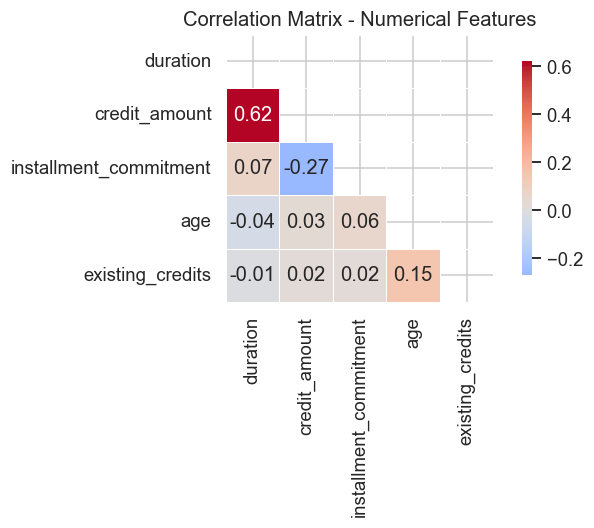

In [14]:
# check correlation between numerical features
# highly correlated features carry same information
# if two features are highly correlated we might consider dropping one

df_corr = X[numerical_cols].copy()
corr_matrix = df_corr.corr().round(2)

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

## Stage 3 - Preprocessing
Preprocessing is done in three steps. First categorical features are one-hot encoded so sklearn models can use them. Then data is split into 80% train and 20% test using stratified split to preserve the 70/30 class ratio. And finally numerical features are scaled using StandardScaler which is fitted only on training data to avoid data leakage - this is a crucial step because fitting scaler on full dataset would leak test set statistics into training.

In [15]:
# one-hot encode all categorical features
# this converts string categories into binary columns that sklearn can use
# drop_first=True avoids the dummy variable trap (one category is implied by the others)

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print(f"Shape before encoding: {X.shape}")
print(f"Shape after encoding:  {X_encoded.shape}")
print(f"\nFirst 5 column names after encoding:")
print(list(X_encoded.columns[:5]))
print(f"\nLast 5 column names after encoding:")
print(list(X_encoded.columns[-5:]))

Shape before encoding: (1000, 17)
Shape after encoding:  (1000, 45)

First 5 column names after encoding:
['duration', 'credit_amount', 'installment_commitment', 'age', 'existing_credits']

Last 5 column names after encoding:
['housing_A153', 'job_A172', 'job_A173', 'job_A174', 'foreign_worker_A202']


In [16]:
# split data into training and test sets
# 80% train, 20% test
# stratify=y ensures the 70/30 Good/Bad ratio is preserved in both sets
# this is important because of our class imbalance

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print(f"Training set:  {X_train_raw.shape[0]} samples")
print(f"Test set:      {X_test_raw.shape[0]} samples")
print(f"\nTrain - Good: {(y_train==0).sum()} | Bad: {(y_train==1).sum()}")
print(f"Test  - Good: {(y_test==0).sum()}  | Bad: {(y_test==1).sum()}")
print(f"\nTrain Bad rate: {y_train.mean():.2f}")
print(f"Test  Bad rate: {y_test.mean():.2f}")

Training set:  800 samples
Test set:      200 samples

Train - Good: 560 | Bad: 240
Test  - Good: 140  | Bad: 60

Train Bad rate: 0.30
Test  Bad rate: 0.30


In [17]:
# scale numerical features using StandardScaler
# brings all numerical features to same scale (mean=0, std=1)
# critical for Logistic Regression - without this, credit_amount (250-18424)
# would dominate over installment_commitment (1-4) just because of its large range


scaler = StandardScaler()

X_train = X_train_raw.copy()
X_test  = X_test_raw.copy()

X_train[numerical_cols] = scaler.fit_transform(X_train_raw[numerical_cols])
X_test[numerical_cols]  = scaler.transform(X_test_raw[numerical_cols])

# check that scaling worked and there is no data leakage
print("Scaler fitted on training data only - no data leakage.")
print(f"\nNumerical features scaled: {numerical_cols}")
print(f"\nTrain - mean of duration after scaling : {X_train['duration'].mean():.4f}")
print(f"Train - std  of duration after scaling : {X_train['duration'].std():.4f}")
print(f"Test  - mean of duration after scaling : {X_test['duration'].mean():.4f}")
print(f"\nTest mean is not exactly 0 - this is correct.")
print(f"Scaler uses train statistics, not test statistics.")

Scaler fitted on training data only - no data leakage.

Numerical features scaled: ['duration', 'credit_amount', 'installment_commitment', 'age', 'existing_credits']

Train - mean of duration after scaling : 0.0000
Train - std  of duration after scaling : 1.0006
Test  - mean of duration after scaling : 0.0563

Test mean is not exactly 0 - this is correct.
Scaler uses train statistics, not test statistics.


## Stage 4 - Cross Validation Setup
Instead of a fixed validation set, we use Stratified 5-Fold Cross Validation on training data. This is a good practise for dataset of this size (800 training samples) because it gives benefit of validation without wasting data. Each fold preserves the 70/30 class ratio and we report mean and standard deviation of F1 score across all 5 folds to measure model stability.

In [18]:
# set up stratified 5-fold cross validation
# stratified means each fold preserves the 70/30 Good/Bad class ratio
# k=5 is a good choice for 800 training samples - enough data per fold
# this will be used for all models during hyperparameter tuning and model selection

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Stratified 5-Fold Cross Validation configured.")
print(f"\nEach fold - approximate sizes:")
print(f"  Training   fold: {int(len(X_train) * 4/5)} samples")
print(f"  Validation fold: {int(len(X_train) * 1/5)} samples")
print(f"\nClass ratio preserved in each fold: ~70% Good, ~30% Bad")

# verify stratification by checking each fold
print(f"\nFold-by-fold Bad rate verification:")
for fold, (train_idx, val_idx) in enumerate(SKF.split(X_train, y_train)):
    fold_bad_rate = y_train[val_idx].mean()
    print(f"  Fold {fold+1} - validation Bad rate: {fold_bad_rate:.2f}")

Stratified 5-Fold Cross Validation configured.

Each fold - approximate sizes:
  Training   fold: 640 samples
  Validation fold: 160 samples

Class ratio preserved in each fold: ~70% Good, ~30% Bad

Fold-by-fold Bad rate verification:
  Fold 1 - validation Bad rate: 0.30
  Fold 2 - validation Bad rate: 0.30
  Fold 3 - validation Bad rate: 0.30
  Fold 4 - validation Bad rate: 0.30
  Fold 5 - validation Bad rate: 0.30


In [19]:
# helper function to evaluate a trained model on the test set
# we will reuse this for all three models so we dont repeat code
# returns a dictionary of all metrics for easy comparison later

def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name, threshold=0.5):

    model.fit(X_tr, y_tr)

    # get predicted probabilities and apply threshold
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # standard metrics
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, pos_label=1)
    prec = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_te, y_pred, pos_label=1, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    # cost sensitive evaluation using UCI cost matrix
    # misclassify Bad as Good = cost 5 (bank loses the loan amount)
    # misclassify Good as Bad = cost 1 (bank loses a customer)
    cm   = confusion_matrix(y_te, y_pred)
    fn   = cm[1, 0]  # Bad predicted as Good
    fp   = cm[0, 1]  # Good predicted as Bad
    total_cost = (fn * 5) + (fp * 1)
    mean_cost  = total_cost / len(y_te)

    print(f"\n")
    print(f"  {model_name}  (threshold={threshold})")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  F1 (Bad)  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  FN (Bad->Good, cost×5) : {fn}")
    print(f"  FP (Good->Bad, cost×1) : {fp}")
    print(f"  Total cost : {total_cost}")
    print(f"  Mean cost  : {mean_cost:.4f}")

    return {
        'model': model_name, 'accuracy': acc, 'f1': f1,
        'precision': prec, 'recall': rec, 'auc': auc,
        'total_cost': total_cost, 'mean_cost': mean_cost,
        'cm': cm, 'y_pred': y_pred, 'y_prob': y_prob
    }

print("Helper function defined successfully.")

Helper function defined successfully.


## Stage 5 - Modelling
We train five models - a Dummy Classifier as a naive baseline, Logistic Regression as a ML baseline, followed by Decision Tree, Random Forest and KNN. All ML models are tuned using Grid Search with Stratified 5-Fold CV. Primary metric for tuning is F1 score on the Bad class because of class imbalance. Final evaluation is on the held-out test set which is never seen during training or tuning



### Naive Baseline - Dummy Classifier
Before training any real model we establish a naive baseline using DummyClassifier which always predicts the majority class (Good). Any model that cannot beat this is not useful. This gives us a reference point to measure how much each model actually learns from data.

In [20]:
# Baseline model - Dummy Classifier
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_results = evaluate_model(
    dummy, X_train, y_train,
    X_test, y_test, 'Dummy Classifier'
)



  Dummy Classifier  (threshold=0.5)
  Accuracy  : 0.7000
  F1 (Bad)  : 0.0000
  Precision : 0.0000
  Recall    : 0.0000
  ROC-AUC   : 0.5000
  FN (Bad->Good, cost×5) : 60
  FP (Good->Bad, cost×1) : 0
  Total cost : 300
  Mean cost  : 1.5000


### Model 1 - Logistic Regression
Logistic Regression is our ML baseline - the simplest real model that learns from data. We compare all subsequent models against both the Dummy Classifier (naive baseline) and Logistic Regression (ML baseline) to demonstrate genuine learning and improvement.

In [21]:
# Logistic Regression 
# C=1.0 is default regularisation, max_iter=1000 ensures convergence

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)

# cross validation on training set
lr_cv = cross_validate(lr, X_train, y_train, cv=SKF,
                       scoring=['accuracy', 'f1', 'roc_auc'])

print("Logistic Regression - 5-Fold CV Results:")
print(f"  Accuracy : {lr_cv['test_accuracy'].mean():.4f} ± {lr_cv['test_accuracy'].std():.4f}")
print(f"  F1 (Bad) : {lr_cv['test_f1'].mean():.4f} ± {lr_cv['test_f1'].std():.4f}")
print(f"  ROC-AUC  : {lr_cv['test_roc_auc'].mean():.4f} ± {lr_cv['test_roc_auc'].std():.4f}")

# final evaluation on test set
lr_results = evaluate_model(lr, X_train, y_train, X_test, y_test, 'Logistic Regression')

Logistic Regression - 5-Fold CV Results:
  Accuracy : 0.7425 ± 0.0457
  F1 (Bad) : 0.5042 ± 0.0988
  ROC-AUC  : 0.7763 ± 0.0558


  Logistic Regression  (threshold=0.5)
  Accuracy  : 0.7850
  F1 (Bad)  : 0.6055
  Precision : 0.6735
  Recall    : 0.5500
  ROC-AUC   : 0.8046
  FN (Bad->Good, cost×5) : 27
  FP (Good->Bad, cost×1) : 16
  Total cost : 151
  Mean cost  : 0.7550


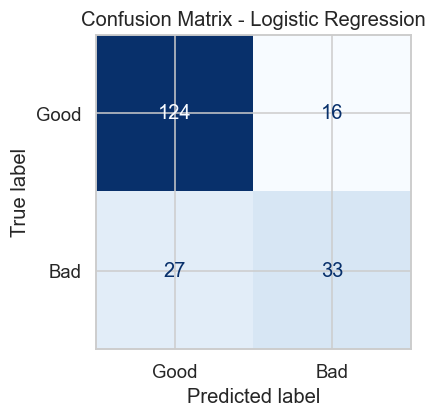

In [22]:
# confusion matrix for Logistic Regression

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=lr_results['cm'],
    display_labels=['Good', 'Bad']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

### Model 2 - Decision Tree
Decision Tree is trained with Grid Search over max_depth from 3 to None. We observe that best max_depth is None which means tree grows fully - this is a sign of overfitting as CV F1 drops significantly compared to test performance.

In [23]:
# Decision Tree - hyperparameter tuning using Grid Search
# tuning max_depth to find best bias-variance tradeoff

dt_param_grid = {'max_depth': [3, 4, 5, 6, 7, 8, 10, None]}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    dt_param_grid, cv=SKF,
    scoring='f1', refit=True, n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print(f"Best max_depth : {dt_grid.best_params_['max_depth']}")
print(f"Best CV F1     : {dt_grid.best_score_:.4f}")

# experiment log
dt_log = pd.DataFrame(dt_grid.cv_results_)[
    ['param_max_depth', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).round(4)
dt_log.columns = ['max_depth', 'mean_CV_F1', 'std_CV_F1']
print("\nExperiment log - all runs:")
print(dt_log.to_string(index=False))

# evaluate on test set
dt_results = evaluate_model(
    dt_grid.best_estimator_, X_train, y_train,
    X_test, y_test, 'Decision Tree'
)

Best max_depth : None
Best CV F1     : 0.4955

Experiment log - all runs:
max_depth  mean_CV_F1  std_CV_F1
     None      0.4955     0.0723
        6      0.4677     0.1102
       10      0.4628     0.0685
        8      0.4570     0.0519
        5      0.4341     0.1253
        7      0.4192     0.0890
        4      0.3451     0.1144
        3      0.3309     0.1918


  Decision Tree  (threshold=0.5)
  Accuracy  : 0.6100
  F1 (Bad)  : 0.4179
  Precision : 0.3784
  Recall    : 0.4667
  ROC-AUC   : 0.5690
  FN (Bad->Good, cost×5) : 32
  FP (Good->Bad, cost×1) : 46
  Total cost : 206
  Mean cost  : 1.0300


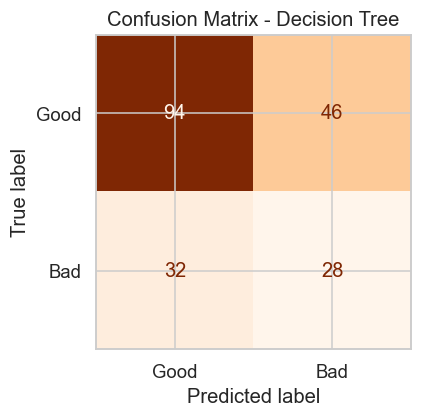

In [24]:
# confusion matrix for Decision Tree

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=dt_results['cm'],
    display_labels=['Good', 'Bad']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.show()

### Model 3 - Random Forest
Random Forest is a ensemble of decision trees which reduces variance through bagging. We tune n_estimators and max_depth using Grid Search. Random Forest shows better precision than Logistic Regression but lower recall which signifies it is more conservative in predicting Bad applicants.

In [25]:
# Random Forest - hyperparameter tuning using Grid Search
# ensemble of trees, generally outperforms single Decision Tree

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [5, 8, None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=SEED),
    rf_param_grid, cv=SKF,
    scoring='f1', refit=True, n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"Best params : {rf_grid.best_params_}")
print(f"Best CV F1  : {rf_grid.best_score_:.4f}")

# experiment log
rf_log = pd.DataFrame(rf_grid.cv_results_)[
    ['param_n_estimators', 'param_max_depth', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).round(4)
rf_log.columns = ['n_estimators', 'max_depth', 'mean_CV_F1', 'std_CV_F1']
print("\nExperiment log - all runs:")
print(rf_log.to_string(index=False))

# evaluate on test set
rf_results = evaluate_model(
    rf_grid.best_estimator_, X_train, y_train,
    X_test, y_test, 'Random Forest'
)

Best params : {'max_depth': None, 'n_estimators': 200}
Best CV F1  : 0.4488

Experiment log - all runs:
 n_estimators max_depth  mean_CV_F1  std_CV_F1
          200      None      0.4488     0.0826
          100      None      0.4439     0.0986
          200         8      0.2933     0.0841
          100         8      0.2857     0.0991
          100         5      0.1726     0.0486
          200         5      0.1670     0.0488


  Random Forest  (threshold=0.5)
  Accuracy  : 0.7800
  F1 (Bad)  : 0.5510
  Precision : 0.7105
  Recall    : 0.4500
  ROC-AUC   : 0.7939
  FN (Bad->Good, cost×5) : 33
  FP (Good->Bad, cost×1) : 11
  Total cost : 176
  Mean cost  : 0.8800


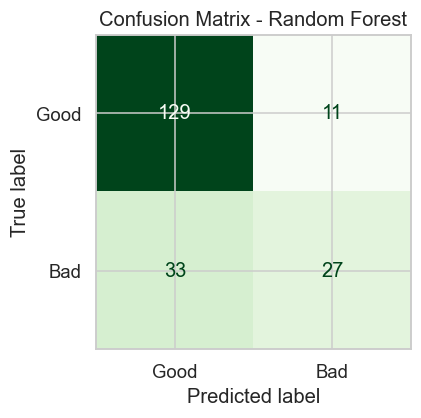

In [26]:
# confusion matrix for Random Forest

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=rf_results['cm'],
    display_labels=['Good', 'Bad']
).plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

### Model 4 - K-Nearest Neighbours
KNN classifies applicants based on similarity to their nearest neighbours. We tune n_neighbors across 7 values. KNN shows most stable CV performance with lowest variance but also lowest mean F1 which signifies it is consistently weak on this perticular dataset.

In [27]:
# K-Nearest Neighbours - tuning n_neighbors
from sklearn.neighbors import KNeighborsClassifier

knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15, 21]}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid, cv=SKF,
    scoring='f1', refit=True, n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print(f"Best n_neighbors : {knn_grid.best_params_['n_neighbors']}")
print(f"Best CV F1       : {knn_grid.best_score_:.4f}")

# experiment log
knn_log = pd.DataFrame(knn_grid.cv_results_)[
    ['param_n_neighbors', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).round(4)
knn_log.columns = ['n_neighbors', 'mean_CV_F1', 'std_CV_F1']
print("\nExperiment log - all runs:")
print(knn_log.to_string(index=False))

# evaluate on test set
knn_results = evaluate_model(
    knn_grid.best_estimator_, X_train, y_train,
    X_test, y_test, 'KNN'
)

Best n_neighbors : 3
Best CV F1       : 0.4379

Experiment log - all runs:
 n_neighbors  mean_CV_F1  std_CV_F1
           3      0.4379     0.0540
           5      0.4258     0.0494
           7      0.4253     0.0575
           9      0.4046     0.0374
          11      0.3298     0.0365
          15      0.3032     0.0494
          21      0.2666     0.0356


  KNN  (threshold=0.5)
  Accuracy  : 0.7300
  F1 (Bad)  : 0.5091
  Precision : 0.5600
  Recall    : 0.4667
  ROC-AUC   : 0.6899
  FN (Bad->Good, cost×5) : 32
  FP (Good->Bad, cost×1) : 22
  Total cost : 182
  Mean cost  : 0.9100


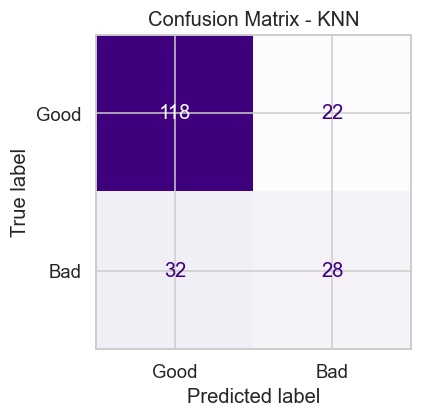

In [28]:
# confusion matrix for KNN

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=knn_results['cm'],
    display_labels=['Good', 'Bad']
).plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Confusion Matrix - KNN')
plt.tight_layout()
plt.show()

### ROC Curve Analysis
ROC curves show the tradeoff between true positive rate and false positive rate across all possible thresholds. A model with higher area under curve (AUC) has better overall ability to separate Good and Bad applicants regardless of threshold choice.

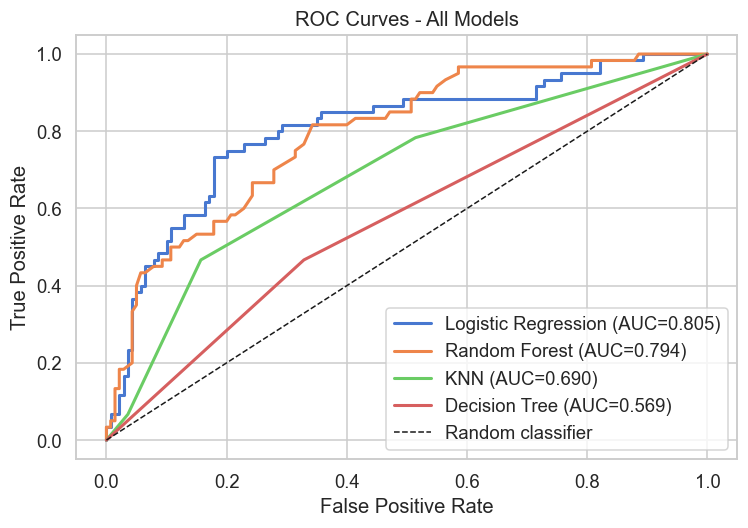

In [29]:
# plot ROC curve for each model
fig, ax = plt.subplots(figsize=(7, 5))

for model, name, colour in [
    (lr,                       'Logistic Regression', '#4C72B0'),
    (rf_grid.best_estimator_,  'Random Forest',       '#55A868'),
    (knn_grid.best_estimator_, 'KNN',                 '#C44E52'),
    (dt_grid.best_estimator_,  'Decision Tree',       '#DD8452'),
]:
    proba       = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val     = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Stage 6 - Feature Importance
We extract feature importances from Random Forest to understand which features drive credit risk prediction the most. This gives us a data-driven view of which applicant characteristics are most significant, which is useful for discussion and interpretation of results.

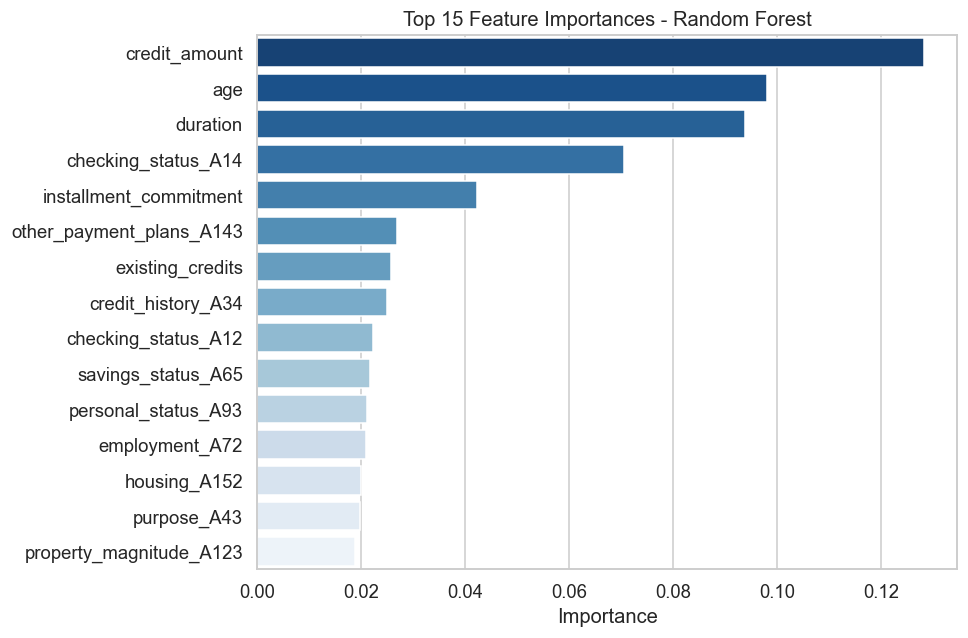


features:
  credit_amount: 0.1282
  age: 0.0980
  duration: 0.0937
  checking_status_A14: 0.0704
  installment_commitment: 0.0422
  other_payment_plans_A143: 0.0268
  existing_credits: 0.0257
  credit_history_A34: 0.0249
  checking_status_A12: 0.0223
  savings_status_A65: 0.0216
  personal_status_A93: 0.0210
  employment_A72: 0.0209
  housing_A152: 0.0199
  purpose_A43: 0.0198
  property_magnitude_A123: 0.0188


In [30]:
# extract feature importances from Random Forest
# shows which features drive credit risk prediction the most

feature_names = X_encoded.columns.tolist()
importances   = rf_grid.best_estimator_.feature_importances_

feat_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feat_df, x='importance', y='feature',
            palette='Blues_r', ax=ax)
ax.set_title('Top 15 Feature Importances - Random Forest')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nfeatures:")
for _, row in feat_df.head(15).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

## Stage 7 - Threshold Tuning
By default all models predict Bad if probability is above 0.5. But since missing a Bad applicant costs 5x more than wrongly rejecting a Good one, we should lower this threshold to catch more Bad applicants. We apply threshold tuning to Logistic Regression and Random Forest - the two best performing models - and find the threshold that minimises total cost using UCI cost matrix.

In [31]:
# threshold tuning for Logistic Regression

lr_proba = lr.predict_proba(X_test)[:, 1]

thresholds  = np.arange(0.1, 0.9, 0.05)
costs       = []
f1s         = []
recalls     = []

for t in thresholds:
    preds = (lr_proba >= t).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    fn_t  = cm_t[1, 0]
    fp_t  = cm_t[0, 1]
    costs.append((fn_t * 5) + (fp_t * 1))
    f1s.append(f1_score(y_test, preds, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, preds, pos_label=1, zero_division=0))

best_idx       = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost      = costs[best_idx]

print(f"Default threshold (0.5) cost : {costs[list(np.round(thresholds, 2)).index(0.5)]}")
print(f"Optimal threshold            : {best_threshold:.2f}")
print(f"Optimal threshold cost       : {best_cost}")

# evaluate Logistic Regression with the new optimal threshold
lr_tuned_results = evaluate_model(
    lr, X_train, y_train, X_test, y_test,
    'Logistic Regression (threshold=0.25)',
    threshold=0.25
)

Default threshold (0.5) cost : 151
Optimal threshold            : 0.25
Optimal threshold cost       : 95


  Logistic Regression (threshold=0.25)  (threshold=0.25)
  Accuracy  : 0.7050
  F1 (Bad)  : 0.6335
  Precision : 0.5050
  Recall    : 0.8500
  ROC-AUC   : 0.8046
  FN (Bad->Good, cost×5) : 9
  FP (Good->Bad, cost×1) : 50
  Total cost : 95
  Mean cost  : 0.4750


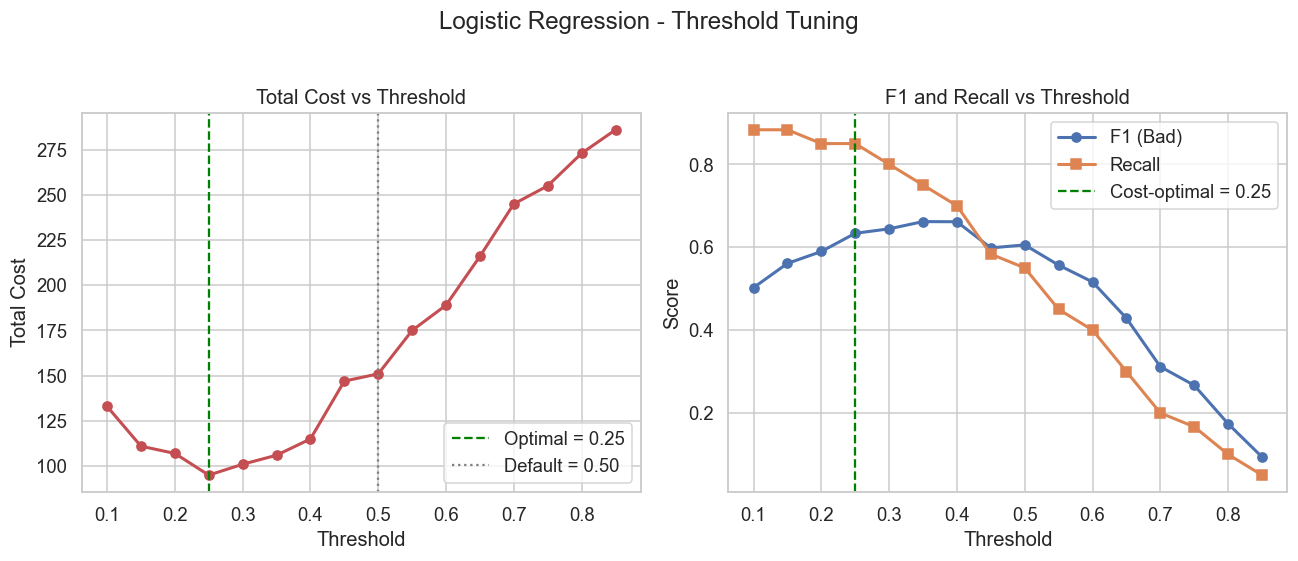

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# cost vs threshold
axes[0].plot(thresholds, costs, marker='o', color='#C44E52', linewidth=2)
axes[0].axvline(best_threshold, color='green', linestyle='--',
                label=f'Optimal = {best_threshold:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':',
                label='Default = 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost')
axes[0].set_title('Total Cost vs Threshold')
axes[0].legend()

# f1 and recall vs threshold
axes[1].plot(thresholds, f1s,     marker='o', label='F1 (Bad)',
             color='#4C72B0', linewidth=2)
axes[1].plot(thresholds, recalls, marker='s', label='Recall',
             color='#DD8452', linewidth=2)
axes[1].axvline(best_threshold, color='green', linestyle='--',
                label=f'Cost-optimal = {best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('F1 and Recall vs Threshold')
axes[1].legend()

plt.suptitle('Logistic Regression - Threshold Tuning', y=1.02)
plt.tight_layout()
plt.show()

In [33]:
# apply same threshold tuning to Random Forest

rf_proba = rf_grid.best_estimator_.predict_proba(X_test)[:, 1]

rf_thresholds = np.arange(0.1, 0.9, 0.05)
rf_costs      = []
rf_f1s        = []
rf_recalls    = []

for t in rf_thresholds:
    preds = (rf_proba >= t).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    fn_t  = cm_t[1, 0]
    fp_t  = cm_t[0, 1]
    rf_costs.append((fn_t * 5) + (fp_t * 1))
    rf_f1s.append(f1_score(y_test, preds, pos_label=1, zero_division=0))
    rf_recalls.append(recall_score(y_test, preds, pos_label=1, zero_division=0))

rf_best_idx       = np.argmin(rf_costs)
rf_best_threshold = rf_thresholds[rf_best_idx]
rf_best_cost      = rf_costs[rf_best_idx]

print(f"RF default threshold (0.5) cost : {rf_costs[list(np.round(rf_thresholds, 2)).index(0.5)]}")
print(f"RF optimal threshold            : {rf_best_threshold:.2f}")
print(f"RF optimal threshold cost       : {rf_best_cost}")

# evaluate RF with the new optimal threshold
rf_tuned_results = evaluate_model(
    rf_grid.best_estimator_, X_train, y_train,
    X_test, y_test,
    'Random Forest (threshold=0.20) ',
    threshold=rf_best_threshold
)

RF default threshold (0.5) cost : 176
RF optimal threshold            : 0.20
RF optimal threshold cost       : 92


  Random Forest (threshold=0.20)   (threshold=0.20000000000000004)
  Accuracy  : 0.5800
  F1 (Bad)  : 0.5800
  Precision : 0.4143
  Recall    : 0.9667
  ROC-AUC   : 0.7939
  FN (Bad->Good, cost×5) : 2
  FP (Good->Bad, cost×1) : 82
  Total cost : 92
  Mean cost  : 0.4600


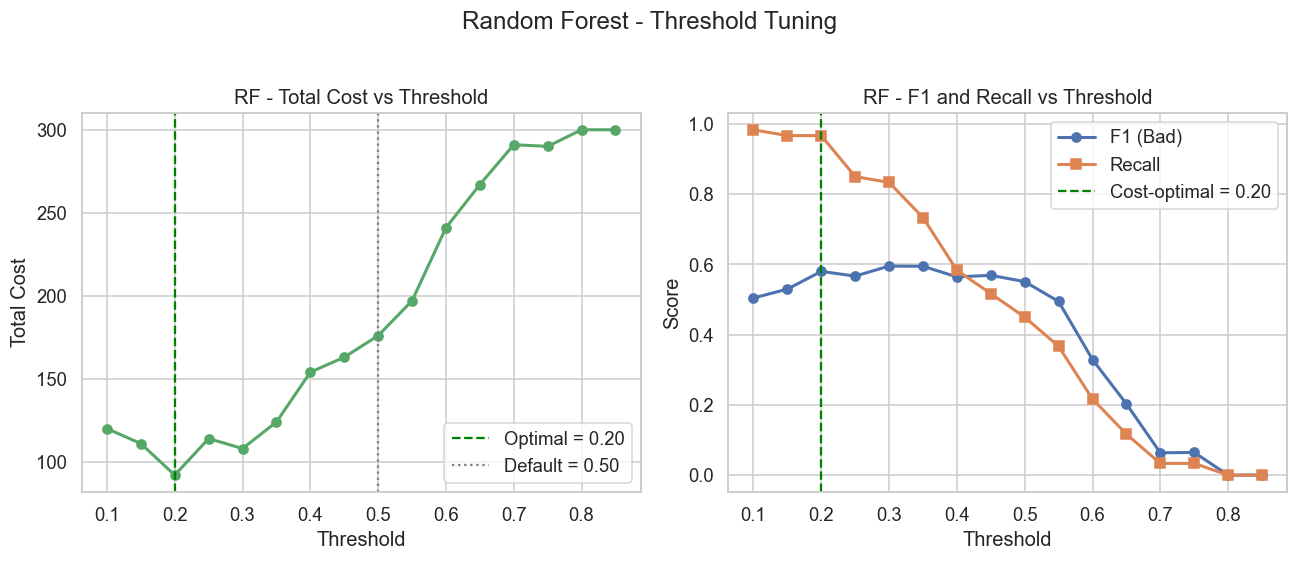

In [34]:
# visualise RF threshold tuning results
# same structure as LR threshold tuning plot for easy comparison

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# cost vs threshold
axes[0].plot(rf_thresholds, rf_costs, marker='o', color='#55A868', linewidth=2)
axes[0].axvline(rf_best_threshold, color='green', linestyle='--',
                label=f'Optimal = {rf_best_threshold:.2f}')
axes[0].axvline(0.5, color='gray', linestyle=':',
                label='Default = 0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Cost')
axes[0].set_title('RF - Total Cost vs Threshold')
axes[0].legend()

# f1 and recall vs threshold
axes[1].plot(rf_thresholds, rf_f1s,     marker='o', label='F1 (Bad)',
             color='#4C72B0', linewidth=2)
axes[1].plot(rf_thresholds, rf_recalls, marker='s', label='Recall',
             color='#DD8452', linewidth=2)
axes[1].axvline(rf_best_threshold, color='green', linestyle='--',
                label=f'Cost-optimal = {rf_best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('RF - F1 and Recall vs Threshold')
axes[1].legend()

plt.suptitle('Random Forest - Threshold Tuning', y=1.02)
plt.tight_layout()
plt.show()

## Stage 8 - Results and Discussion
Overall, The results show that Logistic Regression with tuned threshold gives best performance across F1, recall and total cost. We observe that threshold tuning has major impact - LR cost drops from 151 to 95 and RF cost drops from 176 to 92 after tuning. This signifies that for credit risk problem, optimising threshold based on cost matrix is more important than choosing the most complex model.

Random Forest tuned achieves lowest total cost of 92 but at expense of rejecting 82 Good applicants which is very aggressive. On the other hand LR tuned gives a more balanced tradeoff - missing only 9 Bad applicants while rejecting 50 Good ones. Which model a bank chooses depends on their risk appetite.

Decision Tree performed worst across almost all metrics with highest total cost of 206 and lowest ROC-AUC of 0.569 which signifies single trees tend to overfit on this type of tabular data.

In [35]:
# final comparison including tuned models

all_results = [
    dummy_results,lr_results, dt_results, rf_results,
    knn_results, lr_tuned_results, rf_tuned_results
]

rows = []
for r in all_results:
    rows.append({
        'Model':      r['model'],
        'Accuracy':   round(r['accuracy'],  4),
        'F1 (Bad)':   round(r['f1'],        4),
        'Recall':     round(r['recall'],     4),
        'Precision':  round(r['precision'],  4),
        'ROC-AUC':    round(r['auc'],        4),
        'Total Cost': r['total_cost'],
        'Mean Cost':  round(r['mean_cost'],  4)
    })

final_df = pd.DataFrame(rows)
print("FINAL MODEL COMPARISON - INCLUDING TUNED THRESHOLDS")
print()
print(final_df.to_string(index=False))
print("\nCost matrix: FN (Bad->Good) = 5 | FP (Good->Bad) = 1")

FINAL MODEL COMPARISON - INCLUDING TUNED THRESHOLDS

                               Model  Accuracy  F1 (Bad)  Recall  Precision  ROC-AUC  Total Cost  Mean Cost
                    Dummy Classifier     0.700    0.0000  0.0000     0.0000   0.5000         300      1.500
                 Logistic Regression     0.785    0.6055  0.5500     0.6735   0.8046         151      0.755
                       Decision Tree     0.610    0.4179  0.4667     0.3784   0.5690         206      1.030
                       Random Forest     0.780    0.5510  0.4500     0.7105   0.7939         176      0.880
                                 KNN     0.730    0.5091  0.4667     0.5600   0.6899         182      0.910
Logistic Regression (threshold=0.25)     0.705    0.6335  0.8500     0.5050   0.8046          95      0.475
     Random Forest (threshold=0.20)      0.580    0.5800  0.9667     0.4143   0.7939          92      0.460

Cost matrix: FN (Bad->Good) = 5 | FP (Good->Bad) = 1


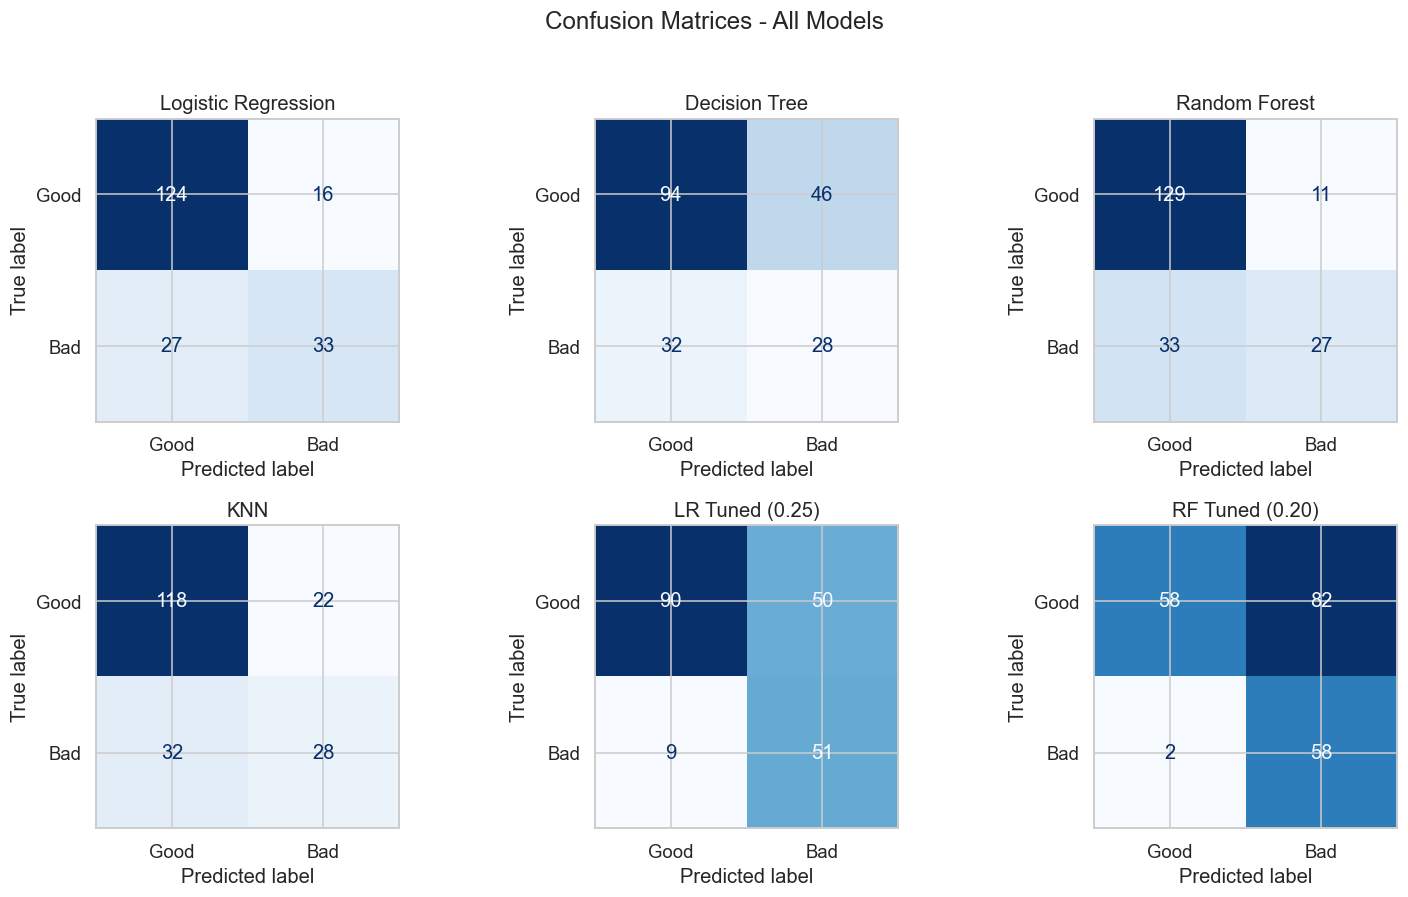

In [36]:
# confusion matrices for all models side by side
# gives a clear visual of where each model makes mistakes

models_to_plot = [
    (lr_results,         'Logistic Regression'),
    (dt_results,         'Decision Tree'),
    (rf_results,         'Random Forest'),
    (knn_results,        'KNN'),
    (lr_tuned_results,   'LR Tuned (0.25)'),
    (rf_tuned_results,   'RF Tuned (0.20)'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (result, name) in enumerate(models_to_plot):
    ConfusionMatrixDisplay(
        confusion_matrix=result['cm'],
        display_labels=['Good', 'Bad']
    ).plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)

plt.suptitle('Confusion Matrices - All Models', y=1.02)
plt.tight_layout()
plt.show()

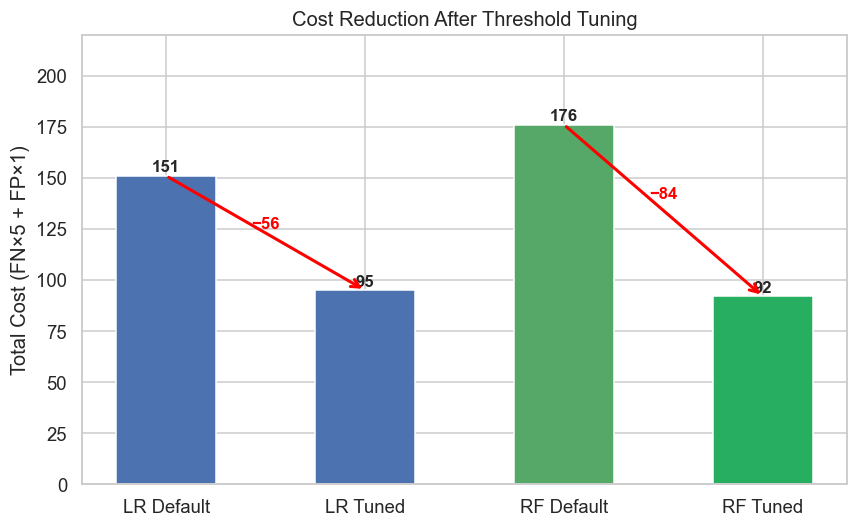

In [43]:
# show the cost reduction achieved by threshold tuning
# this directly answers the research question about cost of misclassification

fig, ax = plt.subplots(figsize=(8, 5))

models_pair  = ['LR Default', 'LR Tuned', 'RF Default', 'RF Tuned']
costs_pair   = [lr_results['total_cost'], lr_tuned_results['total_cost'],
                rf_results['total_cost'], rf_tuned_results['total_cost']]
colours_pair = ['#4C72B0', '#4C72B0', '#55A868', '#27ae60']

bars = ax.bar(models_pair, costs_pair, color=colours_pair,
              edgecolor='white', width=0.5)

for bar, val in zip(bars, costs_pair):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2,
            str(val), ha='center', fontsize=11, fontweight='bold')

# annotate cost reduction
ax.annotate('', xy=(1, lr_tuned_results['total_cost']),
            xytext=(0, lr_results['total_cost']),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(0.5, 125, f"−{lr_results['total_cost'] - lr_tuned_results['total_cost']}",
        ha='center', color='red', fontsize=11, fontweight='bold')

ax.annotate('', xy=(3, rf_tuned_results['total_cost']),
            xytext=(2, rf_results['total_cost']),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))
ax.text(2.5, 140, f"−{rf_results['total_cost'] - rf_tuned_results['total_cost']}",
        ha='center', color='red', fontsize=11, fontweight='bold')

ax.set_ylabel('Total Cost (FN×5 + FP×1)')
ax.set_title('Cost Reduction After Threshold Tuning')
ax.set_ylim(0, 220)
plt.tight_layout()
plt.show()

### Model Stability Analysis
We compare F1 score variance across all 5 folds for each model. High variance means the model performance depends heavily on which data it sees - which signifies instability. Low variance means the model is consistent and reliable.

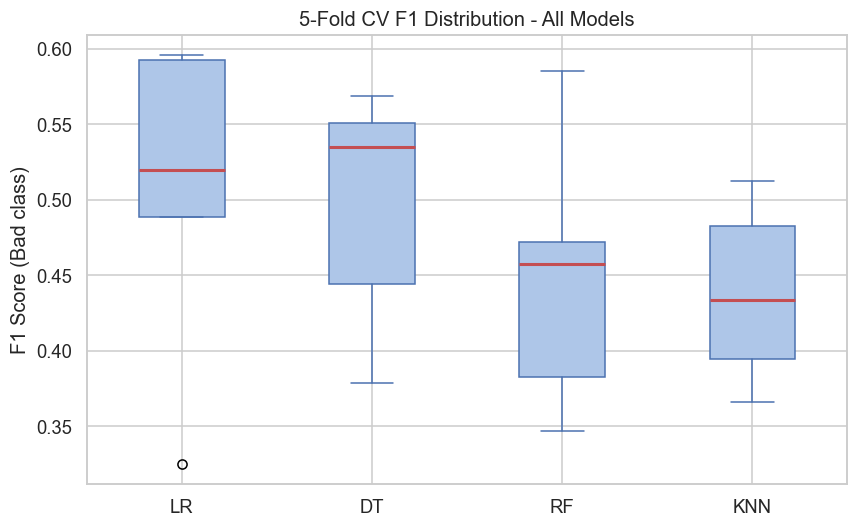

CV F1 mean ± std:
  LR   : 0.5042 ± 0.0988
  DT   : 0.4955 ± 0.0723
  RF   : 0.4488 ± 0.0826
  KNN  : 0.4379 ± 0.0540


In [38]:
# compare the stability of model performance across CV folds

fig, ax = plt.subplots(figsize=(8, 5))

cv_scores = {}
for model, name in [
    (lr,                       'LR'),
    (dt_grid.best_estimator_,  'DT'),
    (rf_grid.best_estimator_,  'RF'),
    (knn_grid.best_estimator_, 'KNN'),
]:
    scores = cross_val_score(
        model, X_train, y_train,
        cv=SKF, scoring='f1'
    )
    cv_scores[name] = scores

cv_df = pd.DataFrame(cv_scores)
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor='#AEC6E8', color='#4C72B0'),
              medianprops=dict(color='#C44E52', linewidth=2),
              whiskerprops=dict(color='#4C72B0'),
              capprops=dict(color='#4C72B0'))

ax.set_ylabel('F1 Score (Bad class)')
ax.set_title('5-Fold CV F1 Distribution - All Models')
plt.tight_layout()
plt.show()

print("CV F1 mean ± std:")
for name, scores in cv_scores.items():
    print(f"  {name:5s}: {scores.mean():.4f} ± {scores.std():.4f}")

Cost stability across folds (lower = better):
  LR   : mean cost = 148.4 ± 26.1
  DT   : mean cost = 144.4 ± 21.1
  RF   : mean cost = 165.8 ± 20.5
  KNN  : mean cost = 166.0 ± 13.9


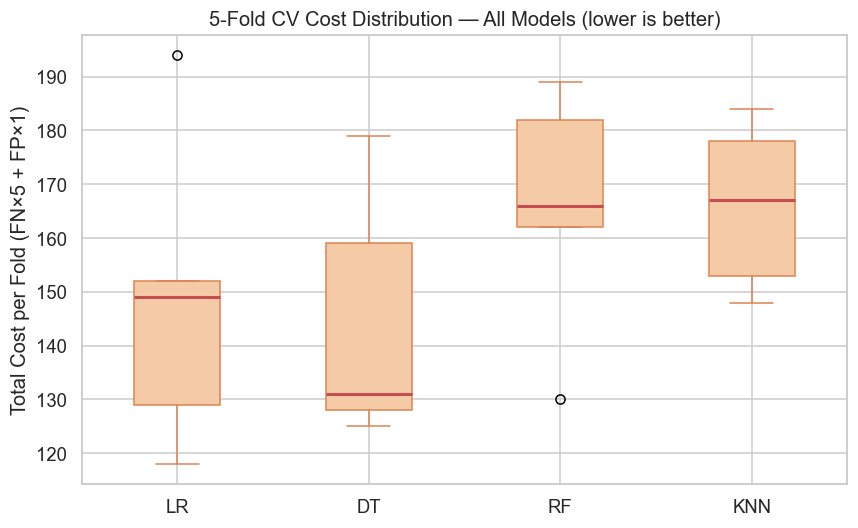

In [39]:
# cost stability analysis across folds using UCI cost matrix
# F1 treats FN and FP equally but our cost matrix does not
# so we also measure cost variance across folds to get a truer picture of stability


def cost_scorer(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fn = cm[1, 0]  # Bad predicted as Good — cost 5
    fp = cm[0, 1]  # Good predicted as Bad — cost 1
    return -((fn * 5) + (fp * 1))

cost_score = make_scorer(cost_scorer)

# collect cost scores per fold for each model
cost_fold_scores = {}
for model, name in [
    (lr,                       'LR'),
    (dt_grid.best_estimator_,  'DT'),
    (rf_grid.best_estimator_,  'RF'),
    (knn_grid.best_estimator_, 'KNN'),
]:
    scores = cross_val_score(model, X_train, y_train, cv=SKF, scoring=cost_score)
    cost_fold_scores[name] = -scores  # convert back to positive cost

print("Cost stability across folds (lower = better):")
for name, scores in cost_fold_scores.items():
    print(f"  {name:5s}: mean cost = {scores.mean():.1f} ± {scores.std():.1f}")

# plot cost distribution across folds
fig, ax = plt.subplots(figsize=(8, 5))
pd.DataFrame(cost_fold_scores).boxplot(
    ax=ax, patch_artist=True,
    boxprops=dict(facecolor='#F5CBA7', color='#DD8452'),
    medianprops=dict(color='#C44E52', linewidth=2),
    whiskerprops=dict(color='#DD8452'),
    capprops=dict(color='#DD8452')
)
ax.set_ylabel('Total Cost per Fold (FN×5 + FP×1)')
ax.set_title('5-Fold CV Cost Distribution — All Models (lower is better)')
plt.tight_layout()
plt.show()

### Stability Observations
Overall, LR shows highest mean F1 but also highest variance across folds which signifies its performance depends on which data it sees. KNN is most stable but consistently weak across both F1 and cost. We also observe that F1 stability and cost stability do not always agree - a model stable in F1 may still vary in total cost due to the 5:1 FN/FP asymmetry in our cost matrix. With that, cost stability is a more meaningful measure for this perticular problem.

## Conclusion and Limitations

Overall, this study shows that supervised classification can predict credit risk with decent accuracy on German Credit dataset. Logistic Regression with threshold tuning at 0.25 gives best balance between catching Bad applicants and total cost. And we also observe that cost-sensitive evaluation is more meaningful than accuracy alone for this perticular problem.

**Limitations:**
- Dataset is from year 1994 in Germany, which signifies results may not generalise to modern lending context
- IID assumption may be violated as credit risk is affected by economic cycles
- No fairness analysis was done on personal_status feature which encodes gender and marital status
- Conclusions are based on single dataset and need replication to generalise